# Inspect Astrometry Concordance FITS

This notebook helps you inspect `concordance_ecdfs.fits`:
- list HDUs and key headers
- pair `DRA` and `DDE` extensions by tile/band
- visualize offset maps and a coarse vector field
- inspect offset magnitude statistics

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["image.origin"] = "lower"


In [2]:
# Update this path if your FITS is somewhere else.
candidate_paths = [
    Path("concordance_ecdfs.fits"),
    Path("../../concordance_ecdfs.fits"),
    Path("/home/shemmati/JAISP/concordance_ecdfs.fits"),
]
FITS_PATH = next((p for p in candidate_paths if p.exists()), None)
if FITS_PATH is None:
    raise FileNotFoundError(
        "Could not find concordance FITS. Set FITS_PATH manually in this cell."
    )
FITS_PATH

PosixPath('../../concordance_ecdfs.fits')

In [3]:
hdul = fits.open(FITS_PATH)
print(f"Opened: {FITS_PATH}")
print(f"Total HDUs: {len(hdul)}")
print("Primary header keys:")
for key in ["CONCRDNC", "DSTEP", "DUNIT", "REFFRAME", "INTERP"]:
    if key in hdul[0].header:
        print(f"  {key}: {hdul[0].header[key]}")

Opened: ../../concordance_ecdfs.fits
Total HDUs: 1729
Primary header keys:
  CONCRDNC: True
  DSTEP: 8
  DUNIT: arcsec
  REFFRAME: euclid_VIS
  INTERP: bilinear


In [4]:
def hdu_shape_dtype(hdu):
    if getattr(hdu, "data", None) is None:
        return None, None
    return tuple(hdu.data.shape), str(hdu.data.dtype)

print("index | extname | shape | dtype")
print("-" * 80)
for i, hdu in enumerate(hdul):
    name = hdu.name
    shape, dtype = hdu_shape_dtype(hdu)
    print(f"{i:5d} | {name:30s} | {str(shape):16s} | {dtype}")

index | extname | shape | dtype
--------------------------------------------------------------------------------
    0 | PRIMARY                        | None             | None
    1 | TILE_X00000_Y00000.U.DRA       | (131, 131)       | >f4
    2 | TILE_X00000_Y00000.U.DDE       | (131, 131)       | >f4
    3 | TILE_X00000_Y00000.G.DRA       | (131, 131)       | >f4
    4 | TILE_X00000_Y00000.G.DDE       | (131, 131)       | >f4
    5 | TILE_X00000_Y00000.R.DRA       | (131, 131)       | >f4
    6 | TILE_X00000_Y00000.R.DDE       | (131, 131)       | >f4
    7 | TILE_X00000_Y00000.I.DRA       | (131, 131)       | >f4
    8 | TILE_X00000_Y00000.I.DDE       | (131, 131)       | >f4
    9 | TILE_X00000_Y00000.Z.DRA       | (131, 131)       | >f4
   10 | TILE_X00000_Y00000.Z.DDE       | (131, 131)       | >f4
   11 | TILE_X00000_Y00000.Y.DRA       | (131, 131)       | >f4
   12 | TILE_X00000_Y00000.Y.DDE       | (131, 131)       | >f4
   13 | TILE_X00000_Y00256.U.DRA       | (131, 131)   

In [5]:
pairs = {}
for i in range(1, len(hdul)):
    name = hdul[i].name
    if name.endswith(".DRA"):
        key = name[:-4]
        pairs.setdefault(key, {})["DRA"] = i
    elif name.endswith(".DDE"):
        key = name[:-4]
        pairs.setdefault(key, {})["DDE"] = i

paired_keys = [k for k, v in pairs.items() if "DRA" in v and "DDE" in v]
print(f"Found {len(pairs)} extension groups, {len(paired_keys)} complete DRA/DDE pairs.")
print("First 10 pairs:")
for k in paired_keys[:10]:
    print(" ", k)

Found 864 extension groups, 864 complete DRA/DDE pairs.
First 10 pairs:
  TILE_X00000_Y00000.U
  TILE_X00000_Y00000.G
  TILE_X00000_Y00000.R
  TILE_X00000_Y00000.I
  TILE_X00000_Y00000.Z
  TILE_X00000_Y00000.Y
  TILE_X00000_Y00256.U
  TILE_X00000_Y00256.G
  TILE_X00000_Y00256.R
  TILE_X00000_Y00256.I


In [6]:
# Pick one extension group to visualize.
# Example format: tile_x00000_y00000.r
pair_key = paired_keys[0]
pair_key

'TILE_X00000_Y00000.U'

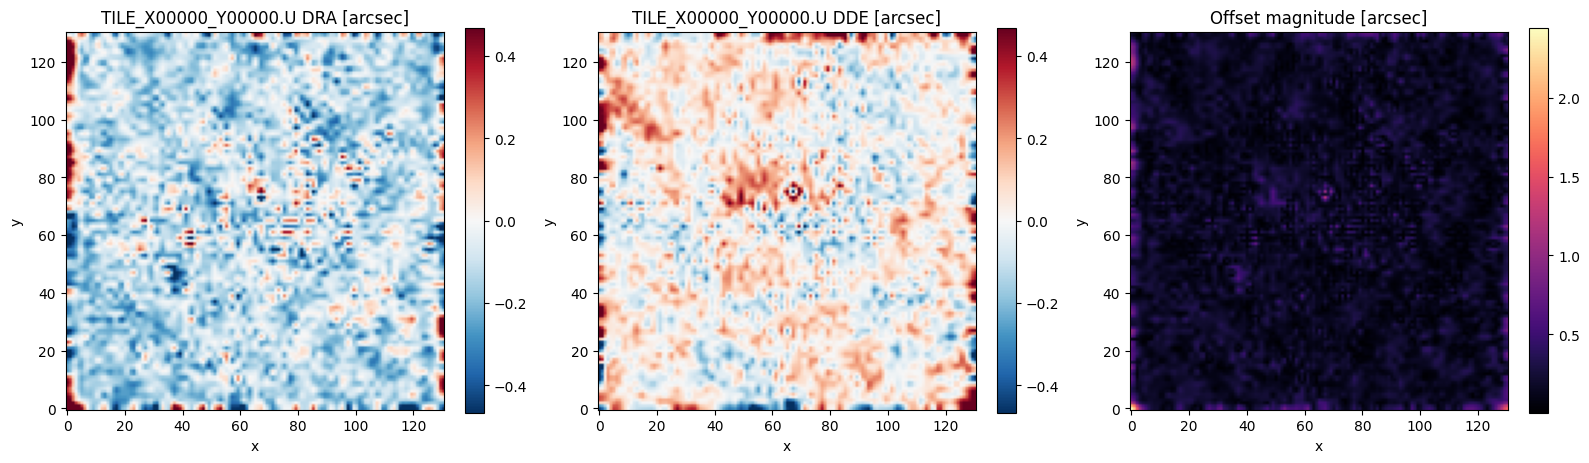

In [7]:
dra = hdul[pairs[pair_key]["DRA"]].data.astype(np.float32)
dde = hdul[pairs[pair_key]["DDE"]].data.astype(np.float32)
mag = np.sqrt(dra**2 + dde**2)

q = np.nanpercentile(np.abs(np.concatenate([dra.ravel(), dde.ravel()])), 99)
q = float(max(q, 1e-6))

fig, ax = plt.subplots(1, 3, figsize=(16, 5))

im0 = ax[0].imshow(dra, cmap="RdBu_r", vmin=-q, vmax=q)
ax[0].set_title(f"{pair_key} DRA [arcsec]")
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(dde, cmap="RdBu_r", vmin=-q, vmax=q)
ax[1].set_title(f"{pair_key} DDE [arcsec]")
plt.colorbar(im1, ax=ax[1], fraction=0.046)

im2 = ax[2].imshow(mag, cmap="magma")
ax[2].set_title("Offset magnitude [arcsec]")
plt.colorbar(im2, ax=ax[2], fraction=0.046)

for a in ax:
    a.set_xlabel("x")
    a.set_ylabel("y")

plt.tight_layout()
plt.show()

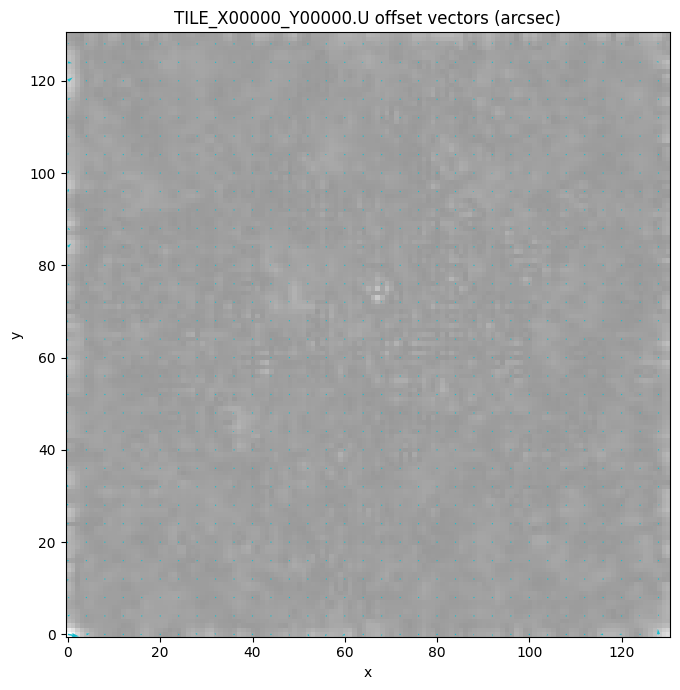

In [8]:
# Coarse vector field view (quiver)
step = max(1, min(dra.shape) // 32)
yy, xx = np.mgrid[0:dra.shape[0]:step, 0:dra.shape[1]:step]
u = dra[::step, ::step]  # x component
v = dde[::step, ::step]  # y component

plt.figure(figsize=(8, 7))
plt.imshow(mag, cmap="gray", alpha=0.4)
plt.quiver(xx, yy, u, v, color="tab:cyan", angles="xy", scale_units="xy", scale=1.0)
plt.title(f"{pair_key} offset vectors (arcsec)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [9]:
def summarize_pair_stats(key):
    dra_k = hdul[pairs[key]["DRA"]].data.astype(np.float32)
    dde_k = hdul[pairs[key]["DDE"]].data.astype(np.float32)
    mag_k = np.sqrt(dra_k**2 + dde_k**2)
    return {
        "key": key,
        "shape": tuple(dra_k.shape),
        "dra_mean": float(np.mean(dra_k)),
        "dde_mean": float(np.mean(dde_k)),
        "mag_p50": float(np.percentile(mag_k, 50)),
        "mag_p95": float(np.percentile(mag_k, 95)),
        "mag_max": float(np.max(mag_k)),
    }

stats = [summarize_pair_stats(k) for k in paired_keys[:10]]
for s in stats:
    print(
        f"{s['key']}: shape={s['shape']} dra_mean={s['dra_mean']:.4f} "
        f"dde_mean={s['dde_mean']:.4f} mag_p95={s['mag_p95']:.4f} max={s['mag_max']:.4f}"
    )

TILE_X00000_Y00000.U: shape=(131, 131) dra_mean=-0.1100 dde_mean=0.0252 mag_p95=0.3676 max=2.4392
TILE_X00000_Y00000.G: shape=(131, 131) dra_mean=-0.0967 dde_mean=0.0175 mag_p95=0.4044 max=2.3835
TILE_X00000_Y00000.R: shape=(131, 131) dra_mean=-0.0981 dde_mean=0.0283 mag_p95=0.4173 max=2.9239
TILE_X00000_Y00000.I: shape=(131, 131) dra_mean=-0.0988 dde_mean=0.0259 mag_p95=0.3999 max=2.4405
TILE_X00000_Y00000.Z: shape=(131, 131) dra_mean=-0.1065 dde_mean=0.0294 mag_p95=0.3942 max=2.7716
TILE_X00000_Y00000.Y: shape=(131, 131) dra_mean=-0.1097 dde_mean=0.0229 mag_p95=0.3765 max=2.4833
TILE_X00000_Y00256.U: shape=(131, 131) dra_mean=-0.1107 dde_mean=0.0183 mag_p95=0.4045 max=2.5752
TILE_X00000_Y00256.G: shape=(131, 131) dra_mean=-0.1117 dde_mean=0.0172 mag_p95=0.4521 max=2.5734
TILE_X00000_Y00256.R: shape=(131, 131) dra_mean=-0.1106 dde_mean=0.0215 mag_p95=0.4419 max=2.3240
TILE_X00000_Y00256.I: shape=(131, 131) dra_mean=-0.1114 dde_mean=0.0260 mag_p95=0.4436 max=2.4116


In [ ]:
# Close when done to release file handles.
# hdul.close()